# Load Data

In [1]:
# Import pandas library to work with data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

In [2]:
# Load the Excel dataset into a DataFrame
df = pd.read_excel(r"C:\project\nlp\dataset -P657.xlsx")
df.head()

,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."


In [3]:
# Display basic information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   1440 non-null   object
 1   rating  1440 non-null   int64 
 2   body    1440 non-null   object
dtypes: int64(1), object(2)
memory usage: 33.9+ KB


In [4]:
# Check how many missing (null) values are present in each column
df.isnull().sum()

title     0
rating    0
body      0
dtype: int64

In [5]:
# Combine 'title' and 'body' columns into a single 'review' column
df['review'] = df['title'] + " " + df['body']
df

,title,rating,body,review
0,Horrible product,1,Very disappointed with the overall performance...,Horrible product Very disappointed with the ov...
1,Camera quality is not like 48 megapixel,3,Camera quality is low,Camera quality is not like 48 megapixel Camera...
2,Overall,4,"Got the mobile on the launch date,Battery must...","Overall Got the mobile on the launch date,Batt..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....,A big no from me 1. It doesn't work with 5.0GH...
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp...",Put your money somewhere else Not worth buying...
...,...,...,...,...
1435,Excellent mobile,5,Excellent mobile,Excellent mobile Excellent mobile
1436,Never expected from samsung,1,"All over mobile performance is very poor, neve...",Never expected from samsung All over mobile pe...
1437,Good value for money,5,Battery life is good but camera clarity could ...,Good value for money Battery life is good but ...
1438,Unreal and whitish display,1,"It's a very bad product, highly dissatisfied.....",Unreal and whitish display It's a very bad pro...


In [6]:
# Create a function to convert rating into sentiment label
def get_sentiment(rating):
    if rating >= 4:
        return "Positive"   # high rating → positive sentiment
    elif rating <= 2:
        return "Negative"   # low rating → negative sentiment
    else:
        return "Neutral"    # medium rating → neutral sentiment

# Apply the function to the 'rating' column and create a new 'sentiment' column
df['sentiment'] = df['rating'].apply(get_sentiment)

In [7]:
# Count how many reviews belong to each sentiment category
df['sentiment'].value_counts()

sentiment
Positive    729
Negative    512
Neutral     199
Name: count, dtype: int64

In [8]:
df = df[['review', 'sentiment']]
df

,review,sentiment
0,Horrible product Very disappointed with the ov...,Negative
1,Camera quality is not like 48 megapixel Camera...,Neutral
2,"Overall Got the mobile on the launch date,Batt...",Positive
3,A big no from me 1. It doesn't work with 5.0GH...,Negative
4,Put your money somewhere else Not worth buying...,Negative
...,...,...
1435,Excellent mobile Excellent mobile,Positive
1436,Never expected from samsung All over mobile pe...,Negative
1437,Good value for money Battery life is good but ...,Positive
1438,Unreal and whitish display It's a very bad pro...,Negative


In [19]:
# Install emoji library to handle emojis in text
!pip install emoji
# Import emoji module
import emoji

# Function to convert emojis into text
def convert_emojis(text):
    return emoji.demojize(str(text))

# Apply function to all reviews and update the 'review' column
df.loc[:, 'review'] = df['review'].apply(convert_emojis)


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:


import langid

# Function to detect language
def detect_language(text):
    try:
        lang, prob = langid.classify(str(text))
        return lang
    except:
        return "unknown"

df['language'] = df['review'].apply(detect_language)


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_6496\1886088688.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['language'] = df['review'].apply(detect_language)


In [21]:
# Check results
print(df[['review','language']].head())

                                              review language
0  Horrible product Very disappointed with the ov...       en
1  Camera quality is not like 48 megapixel Camera...       en
2  Overall Got the mobile on the launch date,Batt...       en
3  A big no from me 1. It doesn't work with 5.0GH...       en
4  Put your money somewhere else Not worth buying...       en


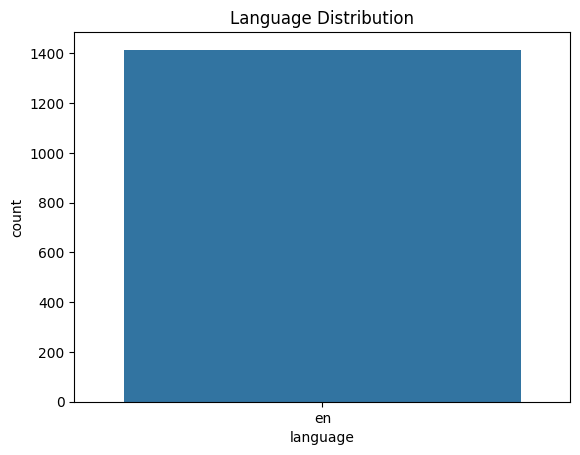

In [22]:
# Create a count plot to show number of reviews in each language
sns.countplot(x='language', data=df)
plt.title("Language Distribution")
plt.show()

“The dataset was predominantly English (~98%), so I filtered non-English reviews to maintain consistency and avoid introducing noise into the model.”

In [13]:
df.head()

,review,sentiment,language
0,Horrible product Very disappointed with the ov...,Negative,en
1,Camera quality is not like 48 megapixel Camera...,Neutral,en
2,"Overall Got the mobile on the launch date,Batt...",Positive,en
3,A big no from me 1. It doesn't work with 5.0GH...,Negative,en
4,Put your money somewhere else Not worth buying...,Negative,en


In [14]:
# Filter the dataset to keep only English ('en') reviews
df = df[df['language'] == 'en']

# Check the shape of the dataset (rows, columns) after filtering
df.shape

(1415, 3)

In [15]:
df.head()

,review,sentiment,language
0,Horrible product Very disappointed with the ov...,Negative,en
1,Camera quality is not like 48 megapixel Camera...,Neutral,en
2,"Overall Got the mobile on the launch date,Batt...",Positive,en
3,A big no from me 1. It doesn't work with 5.0GH...,Negative,en
4,Put your money somewhere else Not worth buying...,Negative,en


In [16]:
import nltk
from nltk.corpus import stopwords  # list of common words like "is", "the"
from nltk.stem import WordNetLemmatizer  # to convert words to base form

In [17]:
# Stopwords are common words like "is", "the", "and" that do not add much meaning.
# We remove them to reduce noise and focus on important words.
# But we keep words like "not", "no", "nor" because they affect sentiment.

In [18]:
# Get English stopwords and keep important words like 'not', 'no', 'nor'
stop_words = set(stopwords.words('english')) - {'not', 'no', 'nor'}

lemmatizer = WordNetLemmatizer()

# Function to clean each review
def clean_text(text):
    text = text.lower()  # convert text to lowercase

    # remove numbers, punctuation, and special characters
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    # split text into words
    words = text.split()

    # remove stopwords (but keep important ones like 'not')
    words = [word for word in words if word not in stop_words]

    # convert words to their base form (e.g., running → run)
    words = [lemmatizer.lemmatize(word) for word in words]

    # join words back into a sentence
    return " ".join(words)

# Apply the cleaning function to all reviews
df['clean_review'] = df['review'].apply(clean_text)

LookupError: 
**********************************************************************
  Resource 'stopwords' not found.
  Please use the NLTK Downloader to obtain the resource:

  >>> import nltk
  >>> nltk.download('stopwords')

  For more information see: https://www.nltk.org/data.html

  Attempted to load 'corpora/stopwords'

  Searched in:
    - 'C:\\Users\\Lenovo/nltk_data'
    - 'C:\\Users\\Lenovo\\AppData\\Local\\Programs\\Python\\Python313\\nltk_data'
    - 'C:\\Users\\Lenovo\\AppData\\Local\\Programs\\Python\\Python313\\share\\nltk_data'
    - 'C:\\Users\\Lenovo\\AppData\\Local\\Programs\\Python\\Python313\\lib\\nltk_data'
    - 'C:\\Users\\Lenovo\\AppData\\Roaming\\nltk_data'
    - 'C:\\nltk_data'
    - 'D:\\nltk_data'
    - 'E:\\nltk_data'
**********************************************************************


In [ ]:
df.head()

In [ ]:
# Create a count plot to show number of reviews in each sentiment category
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

In [ ]:
# Create a new column 'length' which stores the number of characters in each cleaned review
df['length'] = df['clean_review'].apply(len)

# Plot a histogram to see how review lengths are distributed
sns.histplot(df['length'], bins=50)
plt.title("Review Length Distribution")
plt.show()

In [ ]:
# Import WordCloud to create a visual representation of word frequencies
from wordcloud import WordCloud

# Generate a word cloud from all cleaned reviews
# Words that appear more frequently will be shown bigger
wordcloud = WordCloud(width=4000, height=2000,background_color='white',colormap='viridis').generate(" ".join(df['clean_review']))

# Display the word cloud image
plt.imshow(wordcloud)
plt.axis('off')
plt.title("WordCloud")
plt.show()

In [ ]:
# Import Counter to count frequency of words
from collections import Counter

# Combine all cleaned reviews into one big string and split into individual word
# Count how many times each word appears and get top 20 most common words
words = Counter(" ".join(df['clean_review']).split()).most_common(20)

In [ ]:
# Convert the result into a DataFrame for easy plotting
words_df = pd.DataFrame(words, columns=['word', 'count'])

# Create a bar plot showing top 20 words and their frequencies
sns.barplot(x='count', y='word', data=words_df)
plt.title("Top 20 Words")
plt.show()

In [ ]:
df.head()

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
# Applying LabelEncoder to the newly created 'label' column
le = LabelEncoder()
df["sentiment"] = le.fit_transform(df["sentiment"])

df.head()

#### Feature Extraction using TF-IDF

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [ ]:
X = df['clean_review'] # input features
y = df['sentiment'] # target variable

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Convert text into numerical form
tfidf = TfidfVectorizer(max_features=2000,ngram_range=(1,2))

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

#### MODEL BUILDING

##### LOGISTIC REGRESSION

In [ ]:
lr = LogisticRegression(max_iter=1000)

# Train the model on training data
lr.fit(X_train_tfidf, y_train)

In [ ]:
lr_pred = lr.predict(X_test_tfidf)

In [ ]:
print("Accuracy:", accuracy_score(y_test, lr_pred))
print("\nClassification Report for Logistic Regression:\n")
print(classification_report(y_test, lr_pred))

##### Decision Tree

In [ ]:
dt = DecisionTreeClassifier(random_state=42) 
dt.fit(X_train_tfidf, y_train)

In [ ]:
dt_pred = dt.predict(X_test_tfidf)

In [ ]:
print("Accuracy:", accuracy_score(y_test, dt_pred))
print("\nClassification Report for Decision Tree:")
print(classification_report(y_test, dt_pred))


##### SVM

In [ ]:
svm = LinearSVC(random_state=42)

svm.fit(X_train_tfidf, y_train)

In [ ]:
svm_pred = svm.predict(X_test_tfidf)
print("Accuracy:", accuracy_score(y_test, svm_pred))
print("\nClassification Report for SVM:")
print(classification_report(y_test, svm_pred))

##### Random Forest

In [ ]:
rf = RandomForestClassifier(random_state=42) 
rf.fit(X_train_tfidf, y_train)

In [ ]:
rf_pred = rf.predict(X_test_tfidf)
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("\nClassification Report for Random Forest:")
print(classification_report(y_test, rf_pred))

##### Naive Bayes

In [ ]:
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

In [ ]:
nb_pred = nb.predict(X_test_tfidf)
print("Accuracy:", accuracy_score(y_test, nb_pred))

print("\nClassification Report for Naive Bayes:")
print(classification_report(y_test, nb_pred))

##### LightGBM

In [ ]:
lgbm = LGBMClassifier(random_state=42)
lgbm.fit(X_train_tfidf, y_train)

In [ ]:
lgbm_pred = lgbm.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, lgbm_pred))
print("\nClassification Report for LightGBM:")
print(classification_report(y_test, lgbm_pred))

### Metrics Comparison

In [ ]:
results = []

models = [
    ("Logistic Regression", lr_pred),
    ("Naive Bayes", nb_pred),
    ("SVM", svm_pred),
    ("Decision Tree", dt_pred),
    ("Random Forest", rf_pred),
    ("LightGBM", lgbm_pred)  
]

for name, pred in models:
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred,average='weighted'),
        "Recall": recall_score(y_test, pred,average='weighted'),
        "F1 Score": f1_score(y_test, pred,average='weighted')
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1 Score", ascending=False)
results_df

In [ ]:
plt.figure(figsize=(8,4))
sns.barplot( x="Model",y="F1 Score",data=results_df)
plt.title("Model Comparison (F1-Score)")
plt.xticks(rotation=30)
plt.show()

### Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

##### Logistic Regression

In [ ]:
# Define Parameter Grid
lr_param_grid = {
    'C': [0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

In [ ]:
# Initialize Base Model
lr = LogisticRegression(max_iter=1000)

In [ ]:
# Grid Search
lr_grid = GridSearchCV(
    estimator=lr,
    param_grid=lr_param_grid,
    scoring='f1_weighted',
    cv=5,
    n_jobs=-1
)

In [ ]:
lr_grid.fit(X_train_tfidf, y_train)

In [ ]:
lr_best = lr_grid.best_estimator_
print("\nBest Logistic Regression Parameters:")
print(lr_grid.best_params_)

In [ ]:
lr_best_pred = lr_best.predict(X_test_tfidf)

##### Decision Tree

In [ ]:
# Define Parameter Grid
dt_param_grid = {
    "max_depth": [ 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini", "entropy"]
}
# Initialize Base Model
dt = DecisionTreeClassifier(random_state=42)

In [ ]:
# Grid Search
dt_grid = GridSearchCV(
    estimator=dt,
    param_grid=dt_param_grid,
    scoring='f1_weighted',
    cv=3,
    n_jobs=-1
)

dt_grid.fit(X_train_tfidf, y_train)

In [ ]:

dt_best = dt_grid.best_estimator_

print("\nBest Decision Tree Parameters:")
print(dt_grid.best_params_)

In [ ]:
dt_best_pred = dt_best.predict(X_test_tfidf)

##### SVM

In [ ]:
# Define Parameter Grid
svm_params = {'C': [0.10, 0.1, 1, 10], 'loss': ['hinge', 'squared_hinge']}
# Initialize Base Model
svm = LinearSVC()

In [ ]:
svm_grid = GridSearchCV(
    estimator=svm,
    param_grid=svm_params,
    scoring='f1_weighted',
    cv=5,
    n_jobs=-1
)

svm_grid.fit(X_train_tfidf, y_train)

In [ ]:
svm_best = svm_grid.best_estimator_
print("\nBest SVM Parameters:")
print(svm_grid.best_params_)

In [ ]:
svm_best_pred = svm_best.predict(X_test_tfidf)

##### Random Forest

In [ ]:
# Define Parameter Grid
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
# Initialize Base Model
rf = RandomForestClassifier(random_state=42)

In [ ]:
# Grid Search
rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_param_grid,
    scoring='f1_weighted',
    cv=3,
    n_jobs=-1
)

rf_grid.fit(X_train_tfidf, y_train)

In [ ]:
rf_best = rf_grid.best_estimator_

print("\nBest Random Forest Parameters:")
print(rf_grid.best_params_)

In [ ]:
rf_best_pred = rf_best.predict(X_test_tfidf)

##### Naive Bayes

In [ ]:
# Define Parameter Grid
nb_param_grid = {
    'alpha': [0.5, 1.0, 1.5]
}

# Initialize Base Model
nb = MultinomialNB()

In [ ]:
# Grid Search
nb_grid = GridSearchCV(
    estimator=nb,
    param_grid=nb_param_grid,
    scoring='f1_weighted',
    cv=5,
    n_jobs=-1
)

nb_grid.fit(X_train_tfidf, y_train)

In [ ]:
nb_best = nb_grid.best_estimator_

print("\nBest Naive Bayes Parameters:")
print(nb_grid.best_params_)

In [ ]:
nb_best_pred = nb_best.predict(X_test_tfidf)

##### LightGBM

In [ ]:
# Define Parameter Grid
lgbm_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 50]
}

# Initialize Base Model
lgbm = LGBMClassifier(random_state=42)

In [ ]:
# Grid Search
lgbm_grid = GridSearchCV(
    estimator=lgbm,
    param_grid=lgbm_param_grid,
    scoring='f1_weighted',
    cv=3,
    n_jobs=-1,
    verbose=1
)

lgbm_grid.fit(X_train_tfidf, y_train)

In [ ]:
lgbm_best = lgbm_grid.best_estimator_

print("\nBest LightGBM Parameters:")
print(lgbm_grid.best_params_)

In [ ]:
lgbm_best_pred = lgbm_best.predict(X_test_tfidf)

###  Comparison Table for Tuned models

In [ ]:
tuned_results = []

tuned_models = [
    ("Logistic Regression", lr_best_pred),
    ("Naive Bayes", nb_best_pred),
    ("SVM", svm_best_pred),
    ("Decision Tree", dt_best_pred),
    ("Random Forest", rf_best_pred),
    ("LightGBM", lgbm_best_pred)
]

for name, pred in tuned_models:
    tuned_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, average='weighted'),
        "Recall": recall_score(y_test, pred, average='weighted'),
        "F1 Score": f1_score(y_test, pred, average='weighted')
    })

# Convert to DataFrame
results_df = pd.DataFrame(tuned_results)
results_df = results_df.sort_values(by="F1 Score", ascending=False)
results_df

In [ ]:
plt.figure(figsize=(8,4))
sns.barplot( x="Model",y="F1 Score",data=results_df)
plt.title("Tuned Model Comparison (F1-Score)")
plt.xticks(rotation=30)
plt.show()

In [ ]:
!pip install streamlit

In [ ]:
import re
import pickle
from sklearn.pipeline import Pipeline
from lightgbm import LGBMClassifier
from sklearn.preprocessing import FunctionTransformer
import joblib

In [ ]:

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z]", " ", text)
    return text

def preprocess_wrapper(texts):
    return [clean_text(t) for t in texts]



In [ ]:
from sklearn.pipeline import Pipeline
from lightgbm import LGBMClassifier

pipeline = Pipeline([
    ("cleaner", FunctionTransformer(preprocess_wrapper, validate=False)),
    ("vectorizer", tfidf),
    ("model", lgbm_best)
])

pipeline.fit(X_train, y_train)

joblib.dump(pipeline, "pipeline.pkl")